# Where are the best-fit clients? A ZIP-code look at older adults in Berkeley, Oakland and Alameda

**Business question:** For a one-person home support business charging &#36;35 an hour (4-hour minimum), which ZIP codes have the most older households that can likely afford ongoing help *and* are likely to need it?

**Why it matters:** The answer tells me where to spend limited time on flyers, senior center visits and referral partners, instead of guessing.

**Data:** U.S. Census Bureau American Community Survey (ACS) 5-year estimates, 2020-2024. Public and free.

**How to run:** Get a free Census API key and save it in `census_key.txt` in the project folder (see the next cell). Then run the cells top to bottom.

In [31]:
import os, re
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# The Census needs a free key: https://api.census.gov/data/key_signup.html
# Easiest way: save the key in a text file named census_key.txt in the project
# folder (next to README.md). That file is listed in .gitignore, so it never
# goes to GitHub. Never paste the key into this notebook.
API_KEY = os.environ.get("CENSUS_API_KEY")
KEY_FILE = "../census_key.txt"
if not API_KEY and os.path.exists(KEY_FILE):
    API_KEY = open(KEY_FILE, encoding="utf-8-sig").read().strip()
print("Using an API key:", bool(API_KEY))

Using an API key: True


## 1. Settings you can change

- **ZIPS** lists the ZIP code areas I serve. ZIP areas do not match city borders exactly (for example 94608 includes Emeryville), so treat the city label as approximate.
- **INCOME_FLOOR** is the lowest yearly household income I assume can afford ongoing help. Census income comes in brackets, so the floor works best at a bracket edge (&#36;50,000, &#36;60,000, &#36;75,000, &#36;100,000).

In [32]:
YEAR = 2024  # ACS 5-year estimates covering 2020-2024
BASE = f"https://api.census.gov/data/{YEAR}/acs/acs5"

ZIPS = {
    "Berkeley": ["94702", "94703", "94704", "94705", "94707", "94708", "94709", "94710"],
    "Oakland":  ["94601", "94602", "94603", "94605", "94606", "94607", "94608", "94609",
                 "94610", "94611", "94612", "94618", "94619", "94621"],
    "Alameda":  ["94501", "94502"],
}

INCOME_FLOOR = 75000       # yearly household income
RATE, MIN_HOURS = 35, 4    # my launch rate and minimum visit

monthly_cost = RATE * MIN_HOURS * 4.33
print(f"One {MIN_HOURS}-hour visit a week costs a client about ${monthly_cost:,.0f} a month")

zip_to_city = {z: city for city, zs in ZIPS.items() for z in zs}
all_zips = list(zip_to_city)

One 4-hour visit a week costs a client about $606 a month


## 2. Find the right Census variables by their labels

Census variables have codes like `B01001_020E` that mean nothing by themselves. Instead of trusting codes from memory, this cell downloads the Census's own list and picks variables by their **label text**. It then prints what it picked so I can check it, and stops with a clear message if something does not match.

In [33]:
def get(url, params=None):
    params = dict(params or {})
    if API_KEY:
        params["key"] = API_KEY
    r = requests.get(url, params=params, timeout=60)
    if r.status_code != 200:
        raise RuntimeError(f"Census API answered {r.status_code}: {r.text[:300]}")
    try:
        return r.json()
    except ValueError:
        # An answer that is a web page instead of data usually means a missing or invalid key
        title = re.search(r"<title>(.*?)</title>", r.text, re.S)
        title = title.group(1).strip() if title else r.text[:200]
        if "key" in title.lower() or not API_KEY:
            raise PermissionError(
                f"The Census did not send data (it said: {title!r}). Get a free key at "
                "https://api.census.gov/data/key_signup.html, save it in census_key.txt "
                "in the project folder, then run all cells again.")
        raise RuntimeError(f"Census API sent something that is not data: {title!r}")

meta = get(BASE + "/variables.json")["variables"]
print(len(meta), "variables available")

def labels_for(table, contains=(), excludes=()):
    # {variable_code: label} for one table, keeping labels that include every word in `contains`
    out = {}
    for code, info in meta.items():
        if not code.startswith(table + "_") or not code.endswith("E"):
            continue
        label = info.get("label", "")
        if all(c in label for c in contains) and not any(e in label for e in excludes):
            out[code] = label
    return dict(sorted(out.items()))

# Residents 65+ (men and women, six age groups) from table B01001
age_words = ["65 and 66", "67 to 69", "70 to 74", "75 to 79", "80 to 84", "85 years and over"]
age65 = {c: l for c, l in labels_for("B01001").items() if any(a in l for a in age_words)}

# People 65+ living alone, table B09020
alone = labels_for("B09020", contains=["Living alone"], excludes=["Not living alone"])

# People 65+ with an independent living difficulty, table B18107
ild = {c: l for c, l in labels_for("B18107", contains=["With an independent living difficulty"]).items()
       if "65 to 74" in l or "75 years and over" in l}

# Households with a householder 65+, by income bracket, table B19037
hh = labels_for("B19037", contains=["Householder 65 years and over"])
hh_total = [c for c, l in hh.items() if l.endswith("Householder 65 years and over:")]

for name, d in [("65+ residents", age65), ("living alone", alone), ("independent living difficulty", ild)]:
    print(f"\n{name}: {len(d)} variables")
    for c, l in d.items():
        print("  ", c, "|", l)

assert len(age65) == 12, f"Expected 12 age groups, found {len(age65)}. Check the labels above."
assert len(alone) >= 1, "Found no 'living alone' variables in B09020. Check the table labels."
assert len(ild) == 4, f"Expected 4 independent-living variables, found {len(ild)}."
assert len(hh_total) == 1, "Could not find the 65+ households total in B19037."

28475 variables available

65+ residents: 12 variables
   B01001_020E | Estimate!!Total:!!Male:!!65 and 66 years
   B01001_021E | Estimate!!Total:!!Male:!!67 to 69 years
   B01001_022E | Estimate!!Total:!!Male:!!70 to 74 years
   B01001_023E | Estimate!!Total:!!Male:!!75 to 79 years
   B01001_024E | Estimate!!Total:!!Male:!!80 to 84 years
   B01001_025E | Estimate!!Total:!!Male:!!85 years and over
   B01001_044E | Estimate!!Total:!!Female:!!65 and 66 years
   B01001_045E | Estimate!!Total:!!Female:!!67 to 69 years
   B01001_046E | Estimate!!Total:!!Female:!!70 to 74 years
   B01001_047E | Estimate!!Total:!!Female:!!75 to 79 years
   B01001_048E | Estimate!!Total:!!Female:!!80 to 84 years
   B01001_049E | Estimate!!Total:!!Female:!!85 years and over

living alone: 2 variables
   B09020_015E | Estimate!!Total:!!In households:!!In nonfamily households:!!Householder:!!Male:!!Living alone
   B09020_018E | Estimate!!Total:!!In households:!!In nonfamily households:!!Householder:!!Female:!!Liv

In [34]:
def lower_bound(label):
    # lowest dollar amount in an income bracket label like '$75,000 to $99,999'
    last = label.split("!!")[-1]
    if last.startswith("Less than"):
        return 0
    return int(re.search(r"\$([\d,]+)", last).group(1).replace(",", ""))

brackets = {c: lower_bound(l) for c, l in hh.items() if c not in hh_total}
hh_can_pay = [c for c, lo in brackets.items() if lo >= INCOME_FLOOR]
print(f"{len(hh_can_pay)} of {len(brackets)} income brackets are at or above ${INCOME_FLOOR:,}")
for c in hh_can_pay:
    print("  ", hh[c].split('!!')[-1])

5 of 16 income brackets are at or above $75,000
   $75,000 to $99,999
   $100,000 to $124,999
   $125,000 to $149,999
   $150,000 to $199,999
   $200,000 or more


## 3. Download the numbers for my ZIP codes

In [35]:
codes = list(age65) + list(alone) + list(ild) + hh_total + list(brackets)

def pull(codes, zips, chunk=40):
    # The API allows about 50 variables per request, so ask in chunks.
    # If the Census rejects my list of ZIP codes (for example one that is not a
    # ZIP-code area), fall back to asking for every ZIP area and keep mine.
    frames = []
    for i in range(0, len(codes), chunk):
        part = codes[i:i + chunk]
        ask = {"get": "NAME," + ",".join(part)}
        try:
            rows = get(BASE, {**ask, "for": "zip code tabulation area:" + ",".join(zips)})
        except RuntimeError as err:
            print("Specific ZIP list failed, asking for all ZIP areas instead:", str(err)[:120])
            rows = get(BASE, {**ask, "for": "zip code tabulation area:*"})
        df = pd.DataFrame(rows[1:], columns=rows[0])
        df = df.rename(columns={"zip code tabulation area": "zip"}).set_index("zip")
        df = df[df.index.isin(zips)]
        frames.append(df[part].apply(pd.to_numeric, errors="coerce"))
    return pd.concat(frames, axis=1)

raw = pull(codes, all_zips)
raw = raw.where(raw >= 0)  # Census uses large negative numbers for 'not available'
print(raw.shape[0], "ZIP areas downloaded;", raw.isna().any(axis=1).sum(), "have missing values")
missing = [z for z in all_zips if z not in raw.index]
if missing:
    print("Not returned by the Census (probably not ZIP-code areas), left out:", missing)

24 ZIP areas downloaded; 0 have missing values


## 4. Build the scores

- **residents_65plus**, **live_alone_65plus**, **difficulty_65plus**: head counts from the Census.
- **hh_65plus_can_pay**: households with a householder 65+ at or above the income floor.
- **share_difficulty**: share of 65+ residents with an independent living difficulty.
- **target_pool** = households that can pay x share with difficulty. This is a rough pool of households that both can afford help and may need it. It assumes income and difficulty are unrelated, which is not exactly true, so use it to **rank ZIP codes, not to count clients**.

In [36]:
out = pd.DataFrame(index=raw.index)
out["city"] = out.index.map(zip_to_city)
out["residents_65plus"] = raw[list(age65)].sum(axis=1)
out["live_alone_65plus"] = raw[list(alone)].sum(axis=1)
out["difficulty_65plus"] = raw[list(ild)].sum(axis=1)
out["hh_65plus"] = raw[hh_total[0]]
out["hh_65plus_can_pay"] = raw[hh_can_pay].sum(axis=1)
out["share_difficulty"] = out["difficulty_65plus"] / out["residents_65plus"]
out["target_pool"] = out["hh_65plus_can_pay"] * out["share_difficulty"]
out = out.sort_values("target_pool", ascending=False).round(2)
out

,city,residents_65plus,live_alone_65plus,difficulty_65plus,hh_65plus,hh_65plus_can_pay,share_difficulty,target_pool
zip,,,,,,,,
94501,Alameda,10926,2860,1671,6150,3025,0.15,462.64
94610,Oakland,5725,1855,828,3608,2172,0.14,314.13
94602,Oakland,5939,1459,814,3602,2085,0.14,285.77
94605,Oakland,7019,1353,841,4153,2352,0.12,281.81
94611,Oakland,8708,2810,691,5760,3461,0.08,274.64
94601,Oakland,6660,1154,1254,3626,1149,0.19,216.34
94606,Oakland,5512,1564,1488,3089,705,0.27,190.32
94703,Berkeley,3187,931,544,1982,1021,0.17,174.28
94619,Oakland,4408,1062,519,2830,1421,0.12,167.31


## 5. Chart and save the results

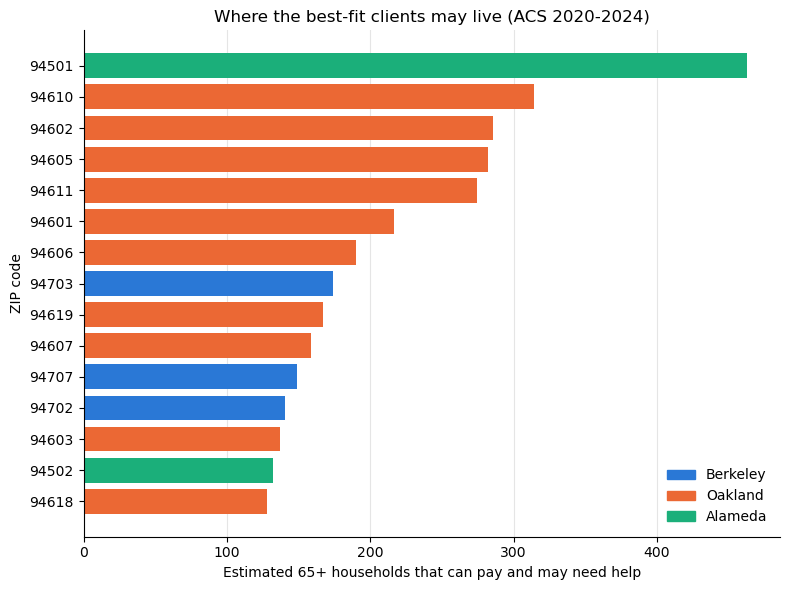

In [37]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

# Colors checked to stay distinct for colorblind readers
colors = {"Berkeley": "#2a78d6", "Oakland": "#eb6834", "Alameda": "#1baf7a"}
top = out.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top["target_pool"], color=[colors[c] for c in top["city"]])
ax.set_xlabel("Estimated 65+ households that can pay and may need help")
ax.set_ylabel("ZIP code")
ax.set_title(f"Where the best-fit clients may live (ACS {YEAR - 4}-{YEAR})")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, list(colors), loc="lower right", frameon=False)
ax.grid(axis="x", color="#e5e5e5", linewidth=0.8)
ax.set_axisbelow(True)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
plt.tight_layout()
fig.savefig(f"{OUT}/top_zip_codes.png", dpi=150)
out.to_csv(f"{OUT}/zip_scores.csv")
plt.show()

## 6. Does the ranking hold if the income floor changes?

My &#36;75,000 floor is an assumption. This section ranks the ZIP codes again at &#36;50,000 and &#36;100,000. If the same ZIP codes stay near the top at every floor, the ranking does not depend much on my guess. If a ZIP code jumps around, I should be careful about it.

The grid at the end shows each ZIP code's rank at the three floors. Shaded boxes are top-five ranks, so a fully shaded row is a safe bet whichever floor I pick.

In [38]:
FLOORS = [50000, 75000, 100000]
share = raw[list(ild)].sum(axis=1) / raw[list(age65)].sum(axis=1)

ranks = pd.DataFrame({"city": out["city"]})
rank_cols = []
for floor in FLOORS:
    cols = [c for c, lo in brackets.items() if lo >= floor]
    pool = (raw[cols].sum(axis=1) * share).fillna(0)
    col = f"rank_at_{floor // 1000}k"
    ranks[col] = pool.rank(ascending=False, method="min").astype(int)
    rank_cols.append(col)

ranks["best_rank"] = ranks[rank_cols].min(axis=1)
ranks["worst_rank"] = ranks[rank_cols].max(axis=1)
ranks = ranks.sort_values("rank_at_75k")

TOP = 5
always = [z for z in ranks.index if (ranks.loc[z, rank_cols] <= TOP).all()]
sometimes = [z for z in ranks.index if (ranks.loc[z, rank_cols] <= TOP).any() and z not in always]
print(f"In the top {TOP} at every income floor:", ", ".join(always) or "none")
print(f"In the top {TOP} at only some floors:  ", ", ".join(sometimes) or "none")
ranks.head(12)

In the top 5 at every income floor: 94501, 94610, 94602, 94605, 94611
In the top 5 at only some floors:   none


,city,rank_at_50k,rank_at_75k,rank_at_100k,best_rank,worst_rank
zip,,,,,,
94501,Alameda,1,1,1,1,1
94610,Oakland,2,2,2,2,2
94602,Oakland,3,3,5,3,5
94605,Oakland,4,4,4,4,4
94611,Oakland,5,5,3,3,5
94601,Oakland,7,6,6,6,7
94606,Oakland,6,7,7,6,7
94703,Berkeley,9,8,10,8,10
94619,Oakland,8,9,8,8,9


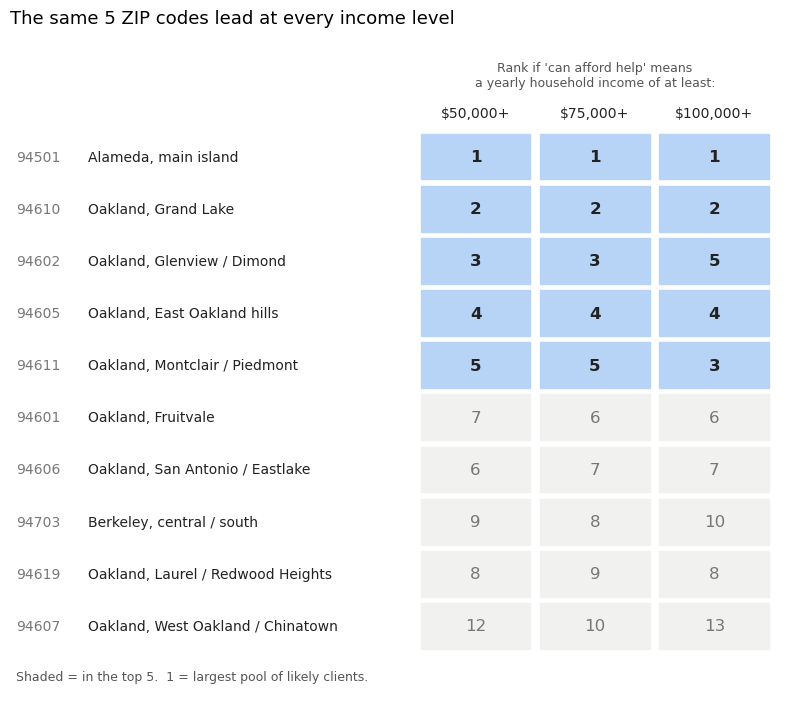

In [39]:
# Approximate neighborhood names, so the grid reads without knowing ZIP codes by heart.
# These are my own labels, not Census names. Edit them freely.
AREA_NAMES = {
    "94501": "Alameda, main island",        "94502": "Alameda, Bay Farm Island",
    "94610": "Oakland, Grand Lake",         "94602": "Oakland, Glenview / Dimond",
    "94605": "Oakland, East Oakland hills", "94611": "Oakland, Montclair / Piedmont",
    "94601": "Oakland, Fruitvale",          "94606": "Oakland, San Antonio / Eastlake",
    "94619": "Oakland, Laurel / Redwood Heights", "94607": "Oakland, West Oakland / Chinatown",
    "94703": "Berkeley, central / south",   "94707": "Berkeley, north hills",
    "94702": "Berkeley, west",
}

# A grid: one row per ZIP code, one box per income floor, the rank written in each box.
show = ranks.head(10)
n = len(show)
fig, ax = plt.subplots(figsize=(8, 0.5 * n + 2.2))
for r, (z, row) in enumerate(show.iterrows()):
    y = n - 1 - r
    ax.text(-3.35, y + 0.5, z, ha="left", va="center", fontsize=10, color="#777777")
    ax.text(-2.75, y + 0.5, AREA_NAMES.get(z, row["city"]), ha="left", va="center", fontsize=10, color="#222222")
    for c, col in enumerate(rank_cols):
        rank = int(row[col])
        top = rank <= TOP
        ax.add_patch(plt.Rectangle((c + 0.04, y + 0.06), 0.92, 0.88, color="#b7d3f6" if top else "#f1f1ef"))
        ax.text(c + 0.5, y + 0.5, str(rank), ha="center", va="center", fontsize=12,
                fontweight="bold" if top else "normal", color="#222222" if top else "#777777")
for c, floor in enumerate(FLOORS):
    ax.text(c + 0.5, n + 0.2, f"\\${floor:,}+", ha="center", va="bottom", fontsize=10, color="#222222")
ax.text(1.5, n + 0.8, "Rank if 'can afford help' means\na yearly household income of at least:",
        ha="center", va="bottom", fontsize=9, color="#555555")
ax.text(-3.35, -0.35, f"Shaded = in the top {TOP}.  1 = largest pool of likely clients.",
        ha="left", va="top", fontsize=9, color="#555555")
ax.set_xlim(-3.4, 3.05)
ax.set_ylim(-0.9, n + 1.9)
ax.axis("off")
title = (f"The same {TOP} ZIP codes lead at every income level" if len(always) == TOP
         else f"{len(always)} of the top {TOP} ZIP codes hold at every income level")
ax.set_title(title, fontsize=13, loc="left")
plt.tight_layout()
fig.savefig(f"{OUT}/rank_by_income_floor.png", dpi=150)
ranks.to_csv(f"{OUT}/rank_by_income_floor.csv")
plt.show()

## 7. What I decided

- **ZIP codes that stay on top at every income floor:** 94501 (Alameda, main island), then 94610, 94602, 94605 and 94611 in Oakland.
- **What stood out:** Berkeley's ZIP codes rank below Alameda and the Oakland hills, mostly because each one is smaller.
- **Action:** Treat these five ZIP codes as my starting list. The later notebooks check them against care need, living alone, language and competitors.

### Limits to remember
- ZIP-code estimates are survey-based and less reliable for small ZIP codes. Treat close rankings as ties.
- The income floor is my assumption, not a measured threshold. Section 6 tests how much it matters.
- This shows where people live, not who wants to hire me. Local conversations still decide that.